Processed files loaded successfully
Logistic Regression Trained Successfully
Decision Tree Trained Successfully
Random Forest Trained Successfully
XGBoost Trained Successfully
[LightGBM] [Info] Number of positive: 399482, number of negative: 399482
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 798964, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Trained Successfully
CatBoost Trained Successfully
Predictions completed successfully
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3              XGBoost   0.99634   0.252610  0.937984  0.398026  0.967200
5             CatBoost   0.99805   0.392157  0.930233  0.551724  0.964185
4

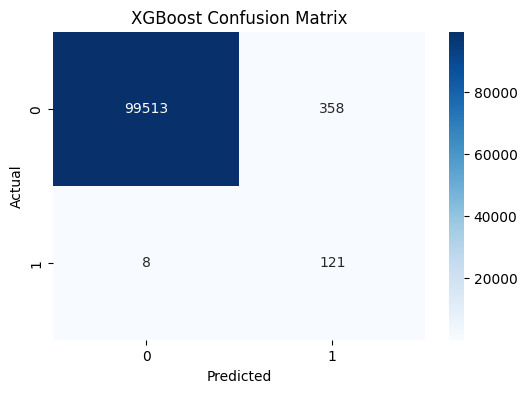


Top 10 Important Features

              Feature  Importance
11  orig_balance_diff    0.477971
10      type_TRANSFER    0.177611
5      newbalanceDest    0.073219
3      newbalanceOrig    0.069211
1              amount    0.069177
9        type_PAYMENT    0.034400
7       type_CASH_OUT    0.028914
2       oldbalanceOrg    0.018412
13  large_transaction    0.015388
12  dest_balance_diff    0.014740


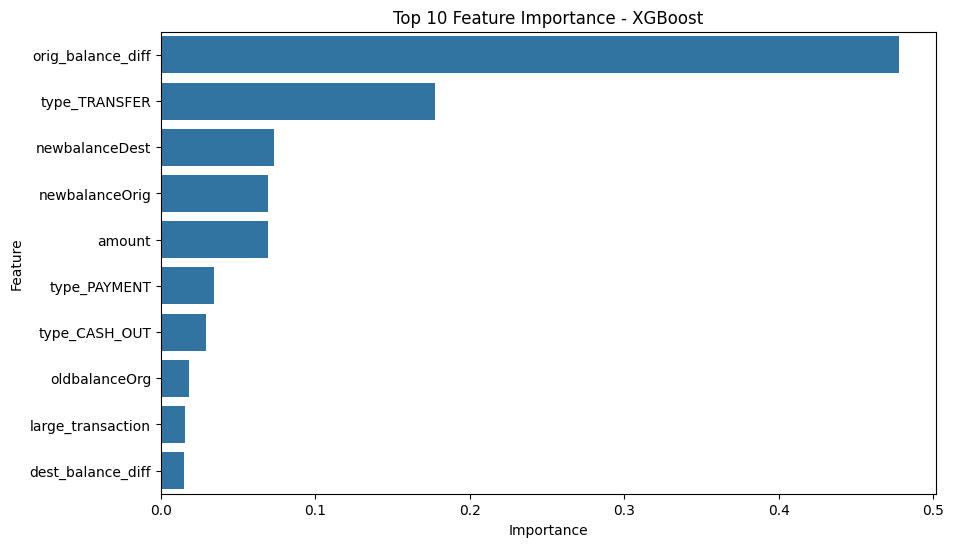


Best model and scaler saved successfully
Model results saved successfully

Model training pipeline completed successfully


In [2]:
# ============================================
# STEP 1 - IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

plt.close('all')


# ============================================
# STEP 2 - LOAD PROCESSED FILES
# ============================================

X_train_scaled = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\X_train_scaled.pkl"
)

X_test_scaled = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\X_test_scaled.pkl"
)

X_train_smote = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\X_train_smote.pkl"
)

X_test = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\X_test.pkl"
)

y_train_smote = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\y_train_smote.pkl"
)

y_test = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\y_test.pkl"
)

scaler = joblib.load(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\data\processed\scaler.pkl"
)

print("Processed files loaded successfully")


# ============================================
# STEP 3 - LOGISTIC REGRESSION
# ============================================

lr_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear'
)

lr_model.fit(
    X_train_scaled,
    y_train_smote
)

print("Logistic Regression Trained Successfully")


# ============================================
# STEP 4 - DECISION TREE
# ============================================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)

print("Decision Tree Trained Successfully")


# ============================================
# STEP 5 - RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest Trained Successfully")


# ============================================
# STEP 6 - XGBOOST
# ============================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost Trained Successfully")


# ============================================
# STEP 7 - LIGHTGBM
# ============================================

lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)

print("LightGBM Trained Successfully")


# ============================================
# STEP 8 - CATBOOST
# ============================================

cat_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat_model.fit(
    X_train_smote,
    y_train_smote
)

print("CatBoost Trained Successfully")


# ============================================
# STEP 9 - MODEL PREDICTIONS
# ============================================

lr_pred = lr_model.predict(X_test_scaled)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

xgb_pred = xgb_model.predict(X_test)

lgbm_pred = lgbm_model.predict(X_test)

cat_pred = cat_model.predict(X_test)

print("Predictions completed successfully")


# ============================================
# STEP 10 - MODEL EVALUATION
# ============================================

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "CatBoost": cat_pred
}

results = []

for model_name, pred in models.items():

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    roc_auc = roc_auc_score(y_test, pred)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])


# ============================================
# STEP 11 - RESULTS TABLE
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
)

results_df = results_df.sort_values(
    by='ROC-AUC',
    ascending=False
)

print(results_df)


# ============================================
# STEP 12 - BEST MODEL REPORT
# ============================================

print("\nClassification Report - XGBoost\n")

print(
    classification_report(
        y_test,
        xgb_pred
    )
)


# ============================================
# STEP 13 - CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ============================================
# STEP 14 - FEATURE IMPORTANCE
# ============================================

feature_names = X_train_smote.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features\n")

print(importance_df.head(10))


# ============================================
# STEP 15 - FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top 10 Feature Importance - XGBoost")

plt.show()


# ============================================
# STEP 16 - SAVE BEST MODEL
# ============================================

joblib.dump(
    xgb_model,
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\models\fraud_detection_model.pkl"
)

joblib.dump(
    scaler,
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\models\scaler.pkl"
)

print("\nBest model and scaler saved successfully")


# ============================================
# STEP 17 - SAVE RESULTS TABLE
# ============================================

results_df.to_csv(
    r"C:\Users\Dell\Desktop\classification project\financial-fraud-detection\reports\model_results.csv",
    index=False
)

print("Model results saved successfully")


# ============================================
# STEP 18 - FINAL MESSAGE
# ============================================

print("\nModel training pipeline completed successfully")